In [52]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 26})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
import importlib
importlib.reload(au)
from scipy.special import erf

In [53]:
data_1 = np.concatenate((np.loadtxt('all_harmonics_output.txt'), 
                      np.loadtxt('2025_11_22_injections.txt'),
                      np.loadtxt('2025_11_28_injections.txt')))
syn_data_1 = np.loadtxt('synthetic_map_no_tsky.txt')
print(f'Number of pointings: {len(np.unique(data_1[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data_1[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data_1[data_1[:, -1] > 0.])/len(data_1)):.2f}%')
print(f'Number of injections: {len(data_1)}')
print('------------------------')
syn_f_idx = 1
syn_DM_idx = 2
syn_S_idx = 3
syn_FWHM_idx = 4
syn_sigma_idx = 5
syn_nharm_idx = 6
print('Synthetic map:')
print(f'Total fraction of recovered injections: \
    {(100*len(syn_data_1[syn_data_1[:, syn_sigma_idx] > 6.])/len(syn_data_1)):.2f}%')
print(f'Number of injections: {len(syn_data_1)}')

RA_idx = 0
Dec_idx = 1
f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
sigma_idx = 8

TPA_idx = data_1[:, 3].astype('int')
FWHM_array = np.load('../profiles/TPA_fwhm.npy')
FWHM = FWHM_array[TPA_idx]
jitter = np.random.uniform(0.85, 1.15, size=len(FWHM)) #to deal with discrete FWHM
data_1[:, FWHM_idx] = FWHM * jitter

from astropy.coordinates import SkyCoord
from astropy import units as u
coords = SkyCoord(ra=data_1[:, RA_idx]*u.deg, dec=data_1[:, Dec_idx]*u.deg, frame='icrs')
b1 = coords.galactic.b


Number of pointings: 15129
Number of days: 8
Total fraction of recovered injections: 30.53%
Number of injections: 271967
------------------------
Synthetic map:
Total fraction of recovered injections:     36.53%
Number of injections: 24446


In [54]:
f_bins = np.logspace(-3, 2.7, 250)
f_dev = 10
DM_bins = np.linspace(0, 700, 250)
DM_dev = 5
S_bins = np.logspace(-2, 1, 250)
S_dev = 10
FWHM_bins = np.logspace(-2.5, np.log10(0.15), 250)
FWHM_dev = 5
RA_bins = np.linspace(0, 360, 250)
RA_dev = 10
Dec_bins = np.linspace(min(data_1[:, Dec_idx]), max(data_1[:, Dec_idx]), 500)
Dec_dev = 40

In [55]:
f_inj_p_smooth, f_sens, f_sens_smooth = au.get_sensitivity(
    data_1, 
    *(f_idx, f_bins, f_dev)
)

DM_inj_p_smooth, DM_sens, DM_sens_smooth = au.get_sensitivity(
    data_1,
    *(DM_idx, DM_bins, DM_dev)
)


S_inj_p_smooth, S_sens, S_sens_smooth = au.get_sensitivity(
    data_1,
    *(S_idx, S_bins, S_dev)
)


FWHM_inj_p_smooth, FWHM_sens, FWHM_sens_smooth = au.get_sensitivity(
    data_1,
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_inj_p_smooth, RA_sens, RA_sens_smooth = au.get_sensitivity(
    data_1,
    *(RA_idx, RA_bins, RA_dev)
)



Dec_inj_p_smooth, Dec_sens, Dec_sens_smooth = au.get_sensitivity(
    data_1,
    *(Dec_idx, Dec_bins, Dec_dev)
)

_, f_pred, f_pred_smooth = au.get_sensitivity(
    data_1, 
    predicted = True,
    *(f_idx, f_bins, f_dev)
)

_, DM_pred, DM_pred_smooth = au.get_sensitivity(
    data_1,
    predicted = True,
    *(DM_idx, DM_bins, DM_dev)
)


_, S_pred, S_pred_smooth = au.get_sensitivity(
    data_1,
    predicted = True,
    *(S_idx, S_bins, S_dev)
)


_, FWHM_pred, FWHM_pred_smooth = au.get_sensitivity(
    data_1,
    predicted = True,
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


_, RA_pred, RA_pred_smooth = au.get_sensitivity(
    data_1,
    predicted = True,
    *(RA_idx, RA_bins, RA_dev)
)



_, Dec_pred, Dec_pred_smooth = au.get_sensitivity(
    data_1,
    predicted = True,
    *(Dec_idx, Dec_bins, Dec_dev)
)

sigma_mask = data_1[:, sigma_idx] >= 6. 

_, f_comp, f_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask], 
    *(f_idx, f_bins, f_dev)
)

_, DM_comp, DM_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(DM_idx, DM_bins, DM_dev)
)


_, S_comp, S_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(S_idx, S_bins, S_dev)
)


_, FWHM_comp, FWHM_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


_, RA_comp, RA_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(RA_idx, RA_bins, RA_dev)
)


_, Dec_comp, Dec_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(Dec_idx, Dec_bins, Dec_dev)
)


/tmp/ipykernel_3139853/1427078627.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


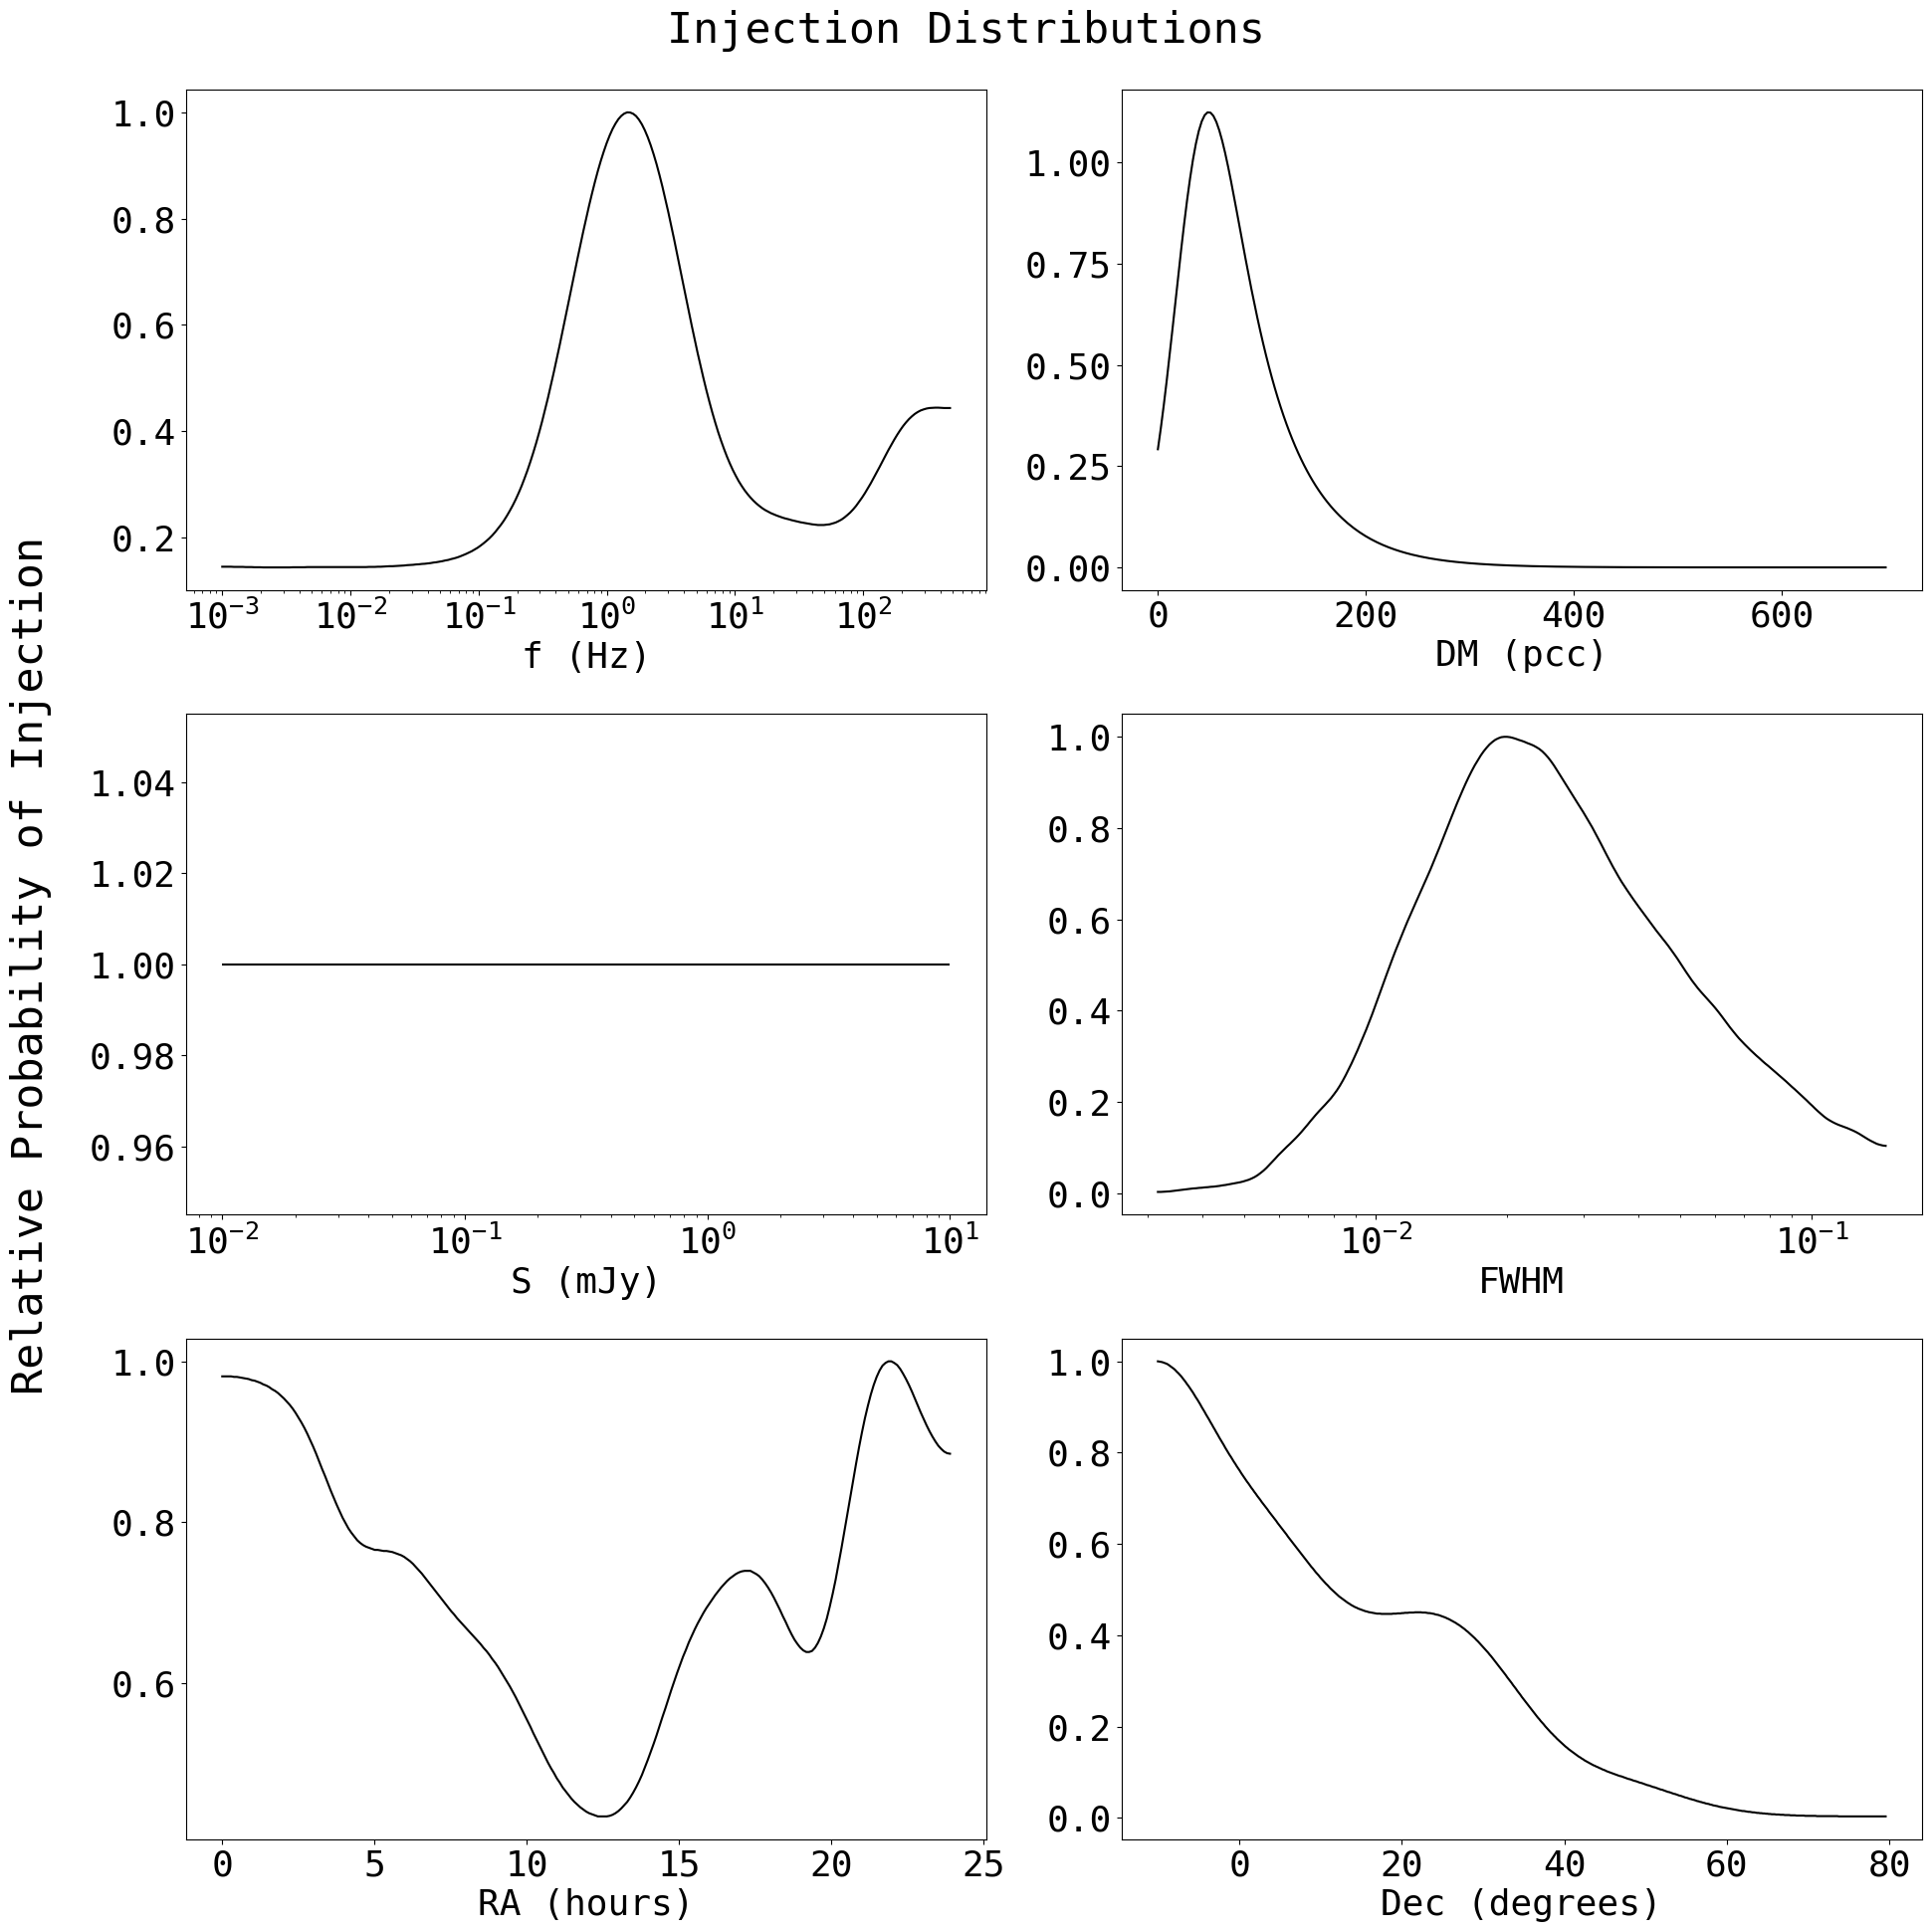

In [56]:
def dm_distribution(x, mu, sig, l):
    gauss = l * np.exp(l * (2 * mu + l * sig**2 - 2 * x) / 2) / 2
    tail = 1 - erf(
        (mu + l * sig**2 - x) / np.sqrt(2) / sig
    )  # complimentary error function

    return gauss * tail / np.sum(gauss * tail)

fig, ax = plt.subplots(3, 2, figsize=(20, 20), layout = 'constrained')
ax = ax.flatten()

ax[0].plot(f_bins[:-1], f_inj_p_smooth / max(f_inj_p_smooth), color='black', label='Actual')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
#au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

#ax[1].plot(DM_bins[:-1], gaussian_filter(DM_inj_p_smooth, 5), color='black', label='Actual')
ax[1].plot(DM_bins, dm_distribution(DM_bins, 24, 24, 0.02) / max(DM_inj_p_smooth), color = 'black')
ax[1].set_xlabel('DM (pcc)')
#au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 5**2))

#ax[2].plot(S_bins[:-1], S_inj_p_smooth, color='black', label='Actual')
ax[2].hlines(1, S_bins[0], S_bins[-1], color = 'black')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
#au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], FWHM_inj_p_smooth / max(FWHM_inj_p_smooth), color='black', label='Actual')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
#au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 3**2))

ax[4].plot(RA_bins[:-1] / 15, RA_inj_p_smooth / max(RA_inj_p_smooth), color='black', label='Actual')
ax[4].set_xlabel('RA (hours)')
#au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

ax[5].plot(Dec_bins[:-1], Dec_inj_p_smooth / max(Dec_inj_p_smooth),  color='black', label='Actual')
ax[5].set_xlabel('Dec (degrees)')
#au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 5**2))

fig.suptitle('Injection Distributions')
fig.supylabel('Relative Probability of Injection')
#handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

/tmp/ipykernel_3139853/3007774362.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


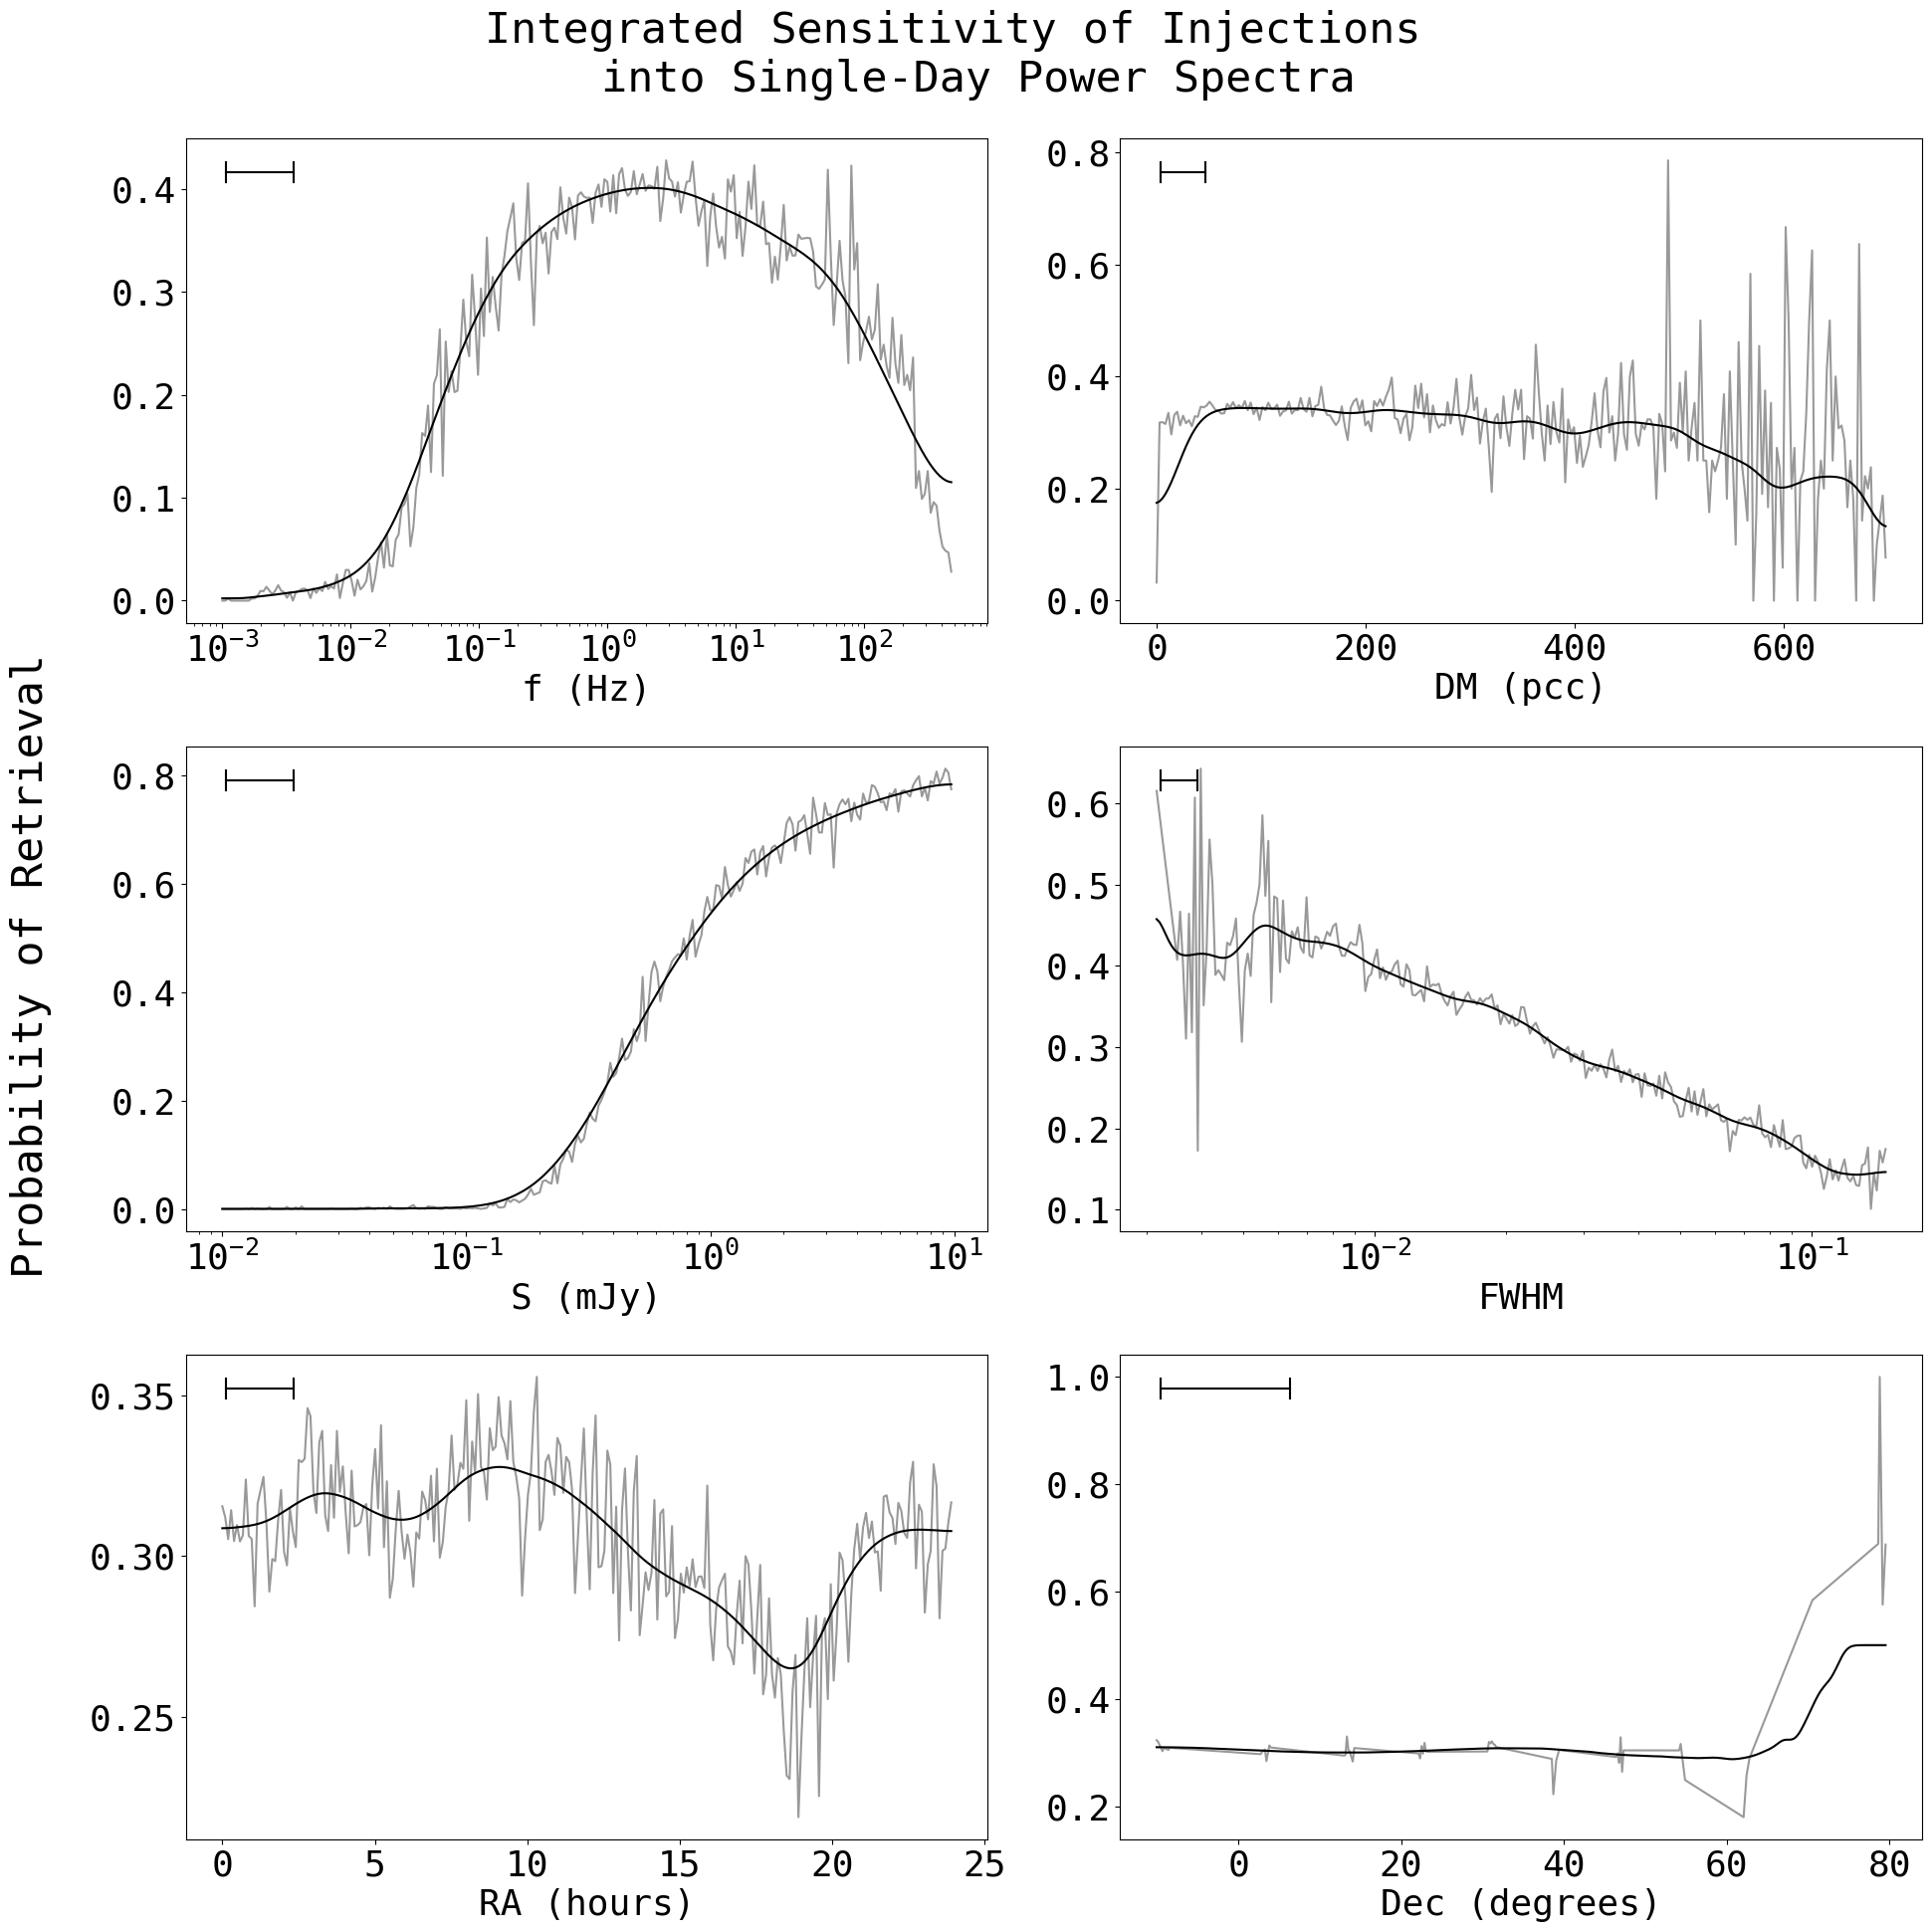

In [57]:
fig, ax = plt.subplots(3, 2, figsize=(20, 20), layout = 'constrained')
ax = ax.flatten()
ax[0].plot(f_bins[:-1], gaussian_filter(f_sens_smooth, 3), color='black', label='Sensitivity')
ax[0].plot(f_bins[:-1], f_sens, alpha=0.4, color='black')
# ax[0].plot(f_bins[:-1], gaussian_filter(f_comp_smooth, 3), color='blue', label='Completeness')
# ax[0].plot(f_bins[:-1], f_comp, alpha=0.4, color='blue')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_sens_smooth, 5), color='black')
ax[1].plot(DM_bins[:-1], DM_sens, alpha=0.4, color='black')
# ax[1].plot(DM_bins[:-1], gaussian_filter(DM_comp_smooth, 3), color='blue')
# ax[1].plot(DM_bins[:-1], DM_comp, alpha=0.4, color='blue')
ax[1].set_xlabel('DM (pcc)')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 5**2))

ax[2].plot(S_bins[:-1], gaussian_filter(S_sens_smooth, 3), color='black')
ax[2].plot(S_bins[:-1], S_sens, alpha=0.4, color='black')
# ax[2].plot(S_bins[:-1], gaussian_filter(S_comp_smooth, 3), color='blue')
# ax[2].plot(S_bins[:-1], S_comp, alpha=0.4, color='blue')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_sens_smooth, 3), color='black')
ax[3].plot(FWHM_bins[:-1], FWHM_sens, alpha=0.4, color='black')
# ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_comp_smooth, 3), color='blue')
# ax[3].plot(FWHM_bins[:-1], FWHM_comp, alpha=0.4, color='blue')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 3**2))

ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_sens_smooth, 3), color='black')
ax[4].plot(RA_bins[:-1] / 15, RA_sens, alpha=0.4, color='black')
# ax[3].plot(RA_bins[:-1], gaussian_filter(RA_comp_smooth, 3), color='blue')
# ax[3].plot(RA_bins[:-1], RA_comp, alpha=0.4, color='blue')
ax[4].set_xlabel('RA (hours)')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_sens_smooth, 5), color='black')
ax[5].plot(Dec_bins[:-1], Dec_sens, alpha=0.4, color='black')
# ax[3].plot(Dec_bins[:-1], gaussian_filter(Dec_comp_smooth, 3), color='blue')
# ax[3].plot(Dec_bins[:-1], Dec_comp, alpha=0.4, color='blue')
ax[5].set_xlabel('Dec (degrees)')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 5**2))

fig.suptitle('Integrated Sensitivity of Injections \n into Single-Day Power Spectra')
fig.supylabel('Probability of Retrieval')
#fig.legend()
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

In [58]:
f_var = np.var(f_sens_smooth)
DM_var = np.var(DM_sens_smooth)
S_var = np.var(S_sens_smooth)
FWHM_var = np.var(FWHM_sens_smooth)
RA_var = np.var(RA_sens_smooth)
Dec_var = np.var(Dec_sens_smooth)

params = ['f', 'DM', 'S', 'FWHM', 'RA', 'Dec']
vars = [f_var, DM_var, S_var, FWHM_var, RA_var, Dec_var]
sorted_var_mask = np.argsort(vars)

print('Standard deviation with parameter:')
print('---------------------------------')
for i in sorted_var_mask[::-1]:
    print(f'{params[i]}: {np.sqrt(vars[i]):.3f}')

Standard deviation with parameter:
---------------------------------
S: 0.315
f: 0.148
FWHM: 0.100
DM: 0.059
Dec: 0.054
RA: 0.017


In [59]:
mask = data_1[:, FWHM_idx] > 0.15
sigma_mask = data_1[:, -1] > 0
print(f'{100* len(data_1[mask & sigma_mask]) / len(data_1[mask]):.1f}%')

11.9%


In [61]:
data_13 = np.loadtxt('13_day_injections_04_06.txt')
print(f'Number of pointings: {len(np.unique(data_13[:, 0:2], axis=0))}')
print(f'Total fraction of recovered injections: {(100*len(data_13[data_13[:, -1] > 0.])/len(data_13)):.2f}%')
print(f'Number of injections: {len(data_13)}')
RA = data_13[:, 0]
Dec = data_13[:, 1]
f = data_13[:, 4]
DM = data_13[:, 5]
S = data_13[:, 6]
fwhm = data_13[:, 7]
coords = SkyCoord(ra=data_13[:, RA_idx]*u.deg, dec=data_13[:, Dec_idx]*u.deg, frame='icrs')
b13 = coords.galactic.b

Number of pointings: 1964
Total fraction of recovered injections: 41.00%
Number of injections: 20070


In [62]:
RA_bins = np.arange(min(RA), max(RA), 1.)
Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 500)
DM_bins = np.arange(min(DM), 200)
S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 500)
fwhm_bins = np.logspace(np.log10(min(fwhm)), np.log10(0.15), 100)

f_dev = 20
DM_dev = 5
S_dev = 20
FWHM_dev = 30
RA_dev = 20
Dec_dev = 10

In [63]:
f_inj_p_smooth, f_sens, f_sens_smooth = au.get_sensitivity(
    data_13, 
    *(f_idx, f_bins, f_dev)
)

DM_inj_p_smooth, DM_sens, DM_sens_smooth = au.get_sensitivity(
    data_13,
    *(DM_idx, DM_bins, DM_dev)
)


S_inj_p_smooth, S_sens, S_sens_smooth = au.get_sensitivity(
    data_13,
    *(S_idx, S_bins, S_dev)
)


FWHM_inj_p_smooth, FWHM_sens, FWHM_sens_smooth = au.get_sensitivity(
    data_13,
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_inj_p_smooth, RA_sens, RA_sens_smooth = au.get_sensitivity(
    data_13,
    *(RA_idx, RA_bins, RA_dev)
)



Dec_inj_p_smooth, Dec_sens, Dec_sens_smooth = au.get_sensitivity(
    data_13,
    *(Dec_idx, Dec_bins, Dec_dev)
)

_, f_pred, f_pred_smooth = au.get_sensitivity(
    data_13, 
    predicted = True,
    *(f_idx, f_bins, f_dev)
)

_, DM_pred, DM_pred_smooth = au.get_sensitivity(
    data_13,
    predicted = True,
    *(DM_idx, DM_bins, DM_dev)
)


_, S_pred, S_pred_smooth = au.get_sensitivity(
    data_13,
    predicted = True,
    *(S_idx, S_bins, S_dev)
)


_, FWHM_pred, FWHM_pred_smooth = au.get_sensitivity(
    data_13,
    predicted = True,
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


_, RA_pred, RA_pred_smooth = au.get_sensitivity(
    data_13,
    predicted = True,
    *(RA_idx, RA_bins, RA_dev)
)



_, Dec_pred, Dec_pred_smooth = au.get_sensitivity(
    data_13,
    predicted = True,
    *(Dec_idx, Dec_bins, Dec_dev)
)

sigma_mask = data_13[:, sigma_idx] >= 6. 

_, f_comp, f_comp_smooth = au.get_sensitivity(
    data_13[sigma_mask], 
    *(f_idx, f_bins, f_dev)
)

_, DM_comp, DM_comp_smooth = au.get_sensitivity(
    data_13[sigma_mask],
    *(DM_idx, DM_bins, DM_dev)
)


_, S_comp, S_comp_smooth = au.get_sensitivity(
    data_13[sigma_mask],
    *(S_idx, S_bins, S_dev)
)


_, FWHM_comp, FWHM_comp_smooth = au.get_sensitivity(
    data_13[sigma_mask],
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


_, RA_comp, RA_comp_smooth = au.get_sensitivity(
    data_13[sigma_mask],
    *(RA_idx, RA_bins, RA_dev)
)


_, Dec_comp, Dec_comp_smooth = au.get_sensitivity(
    data_13[sigma_mask],
    *(Dec_idx, Dec_bins, Dec_dev)
)


/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


/tmp/ipykernel_3139853/1837737607.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


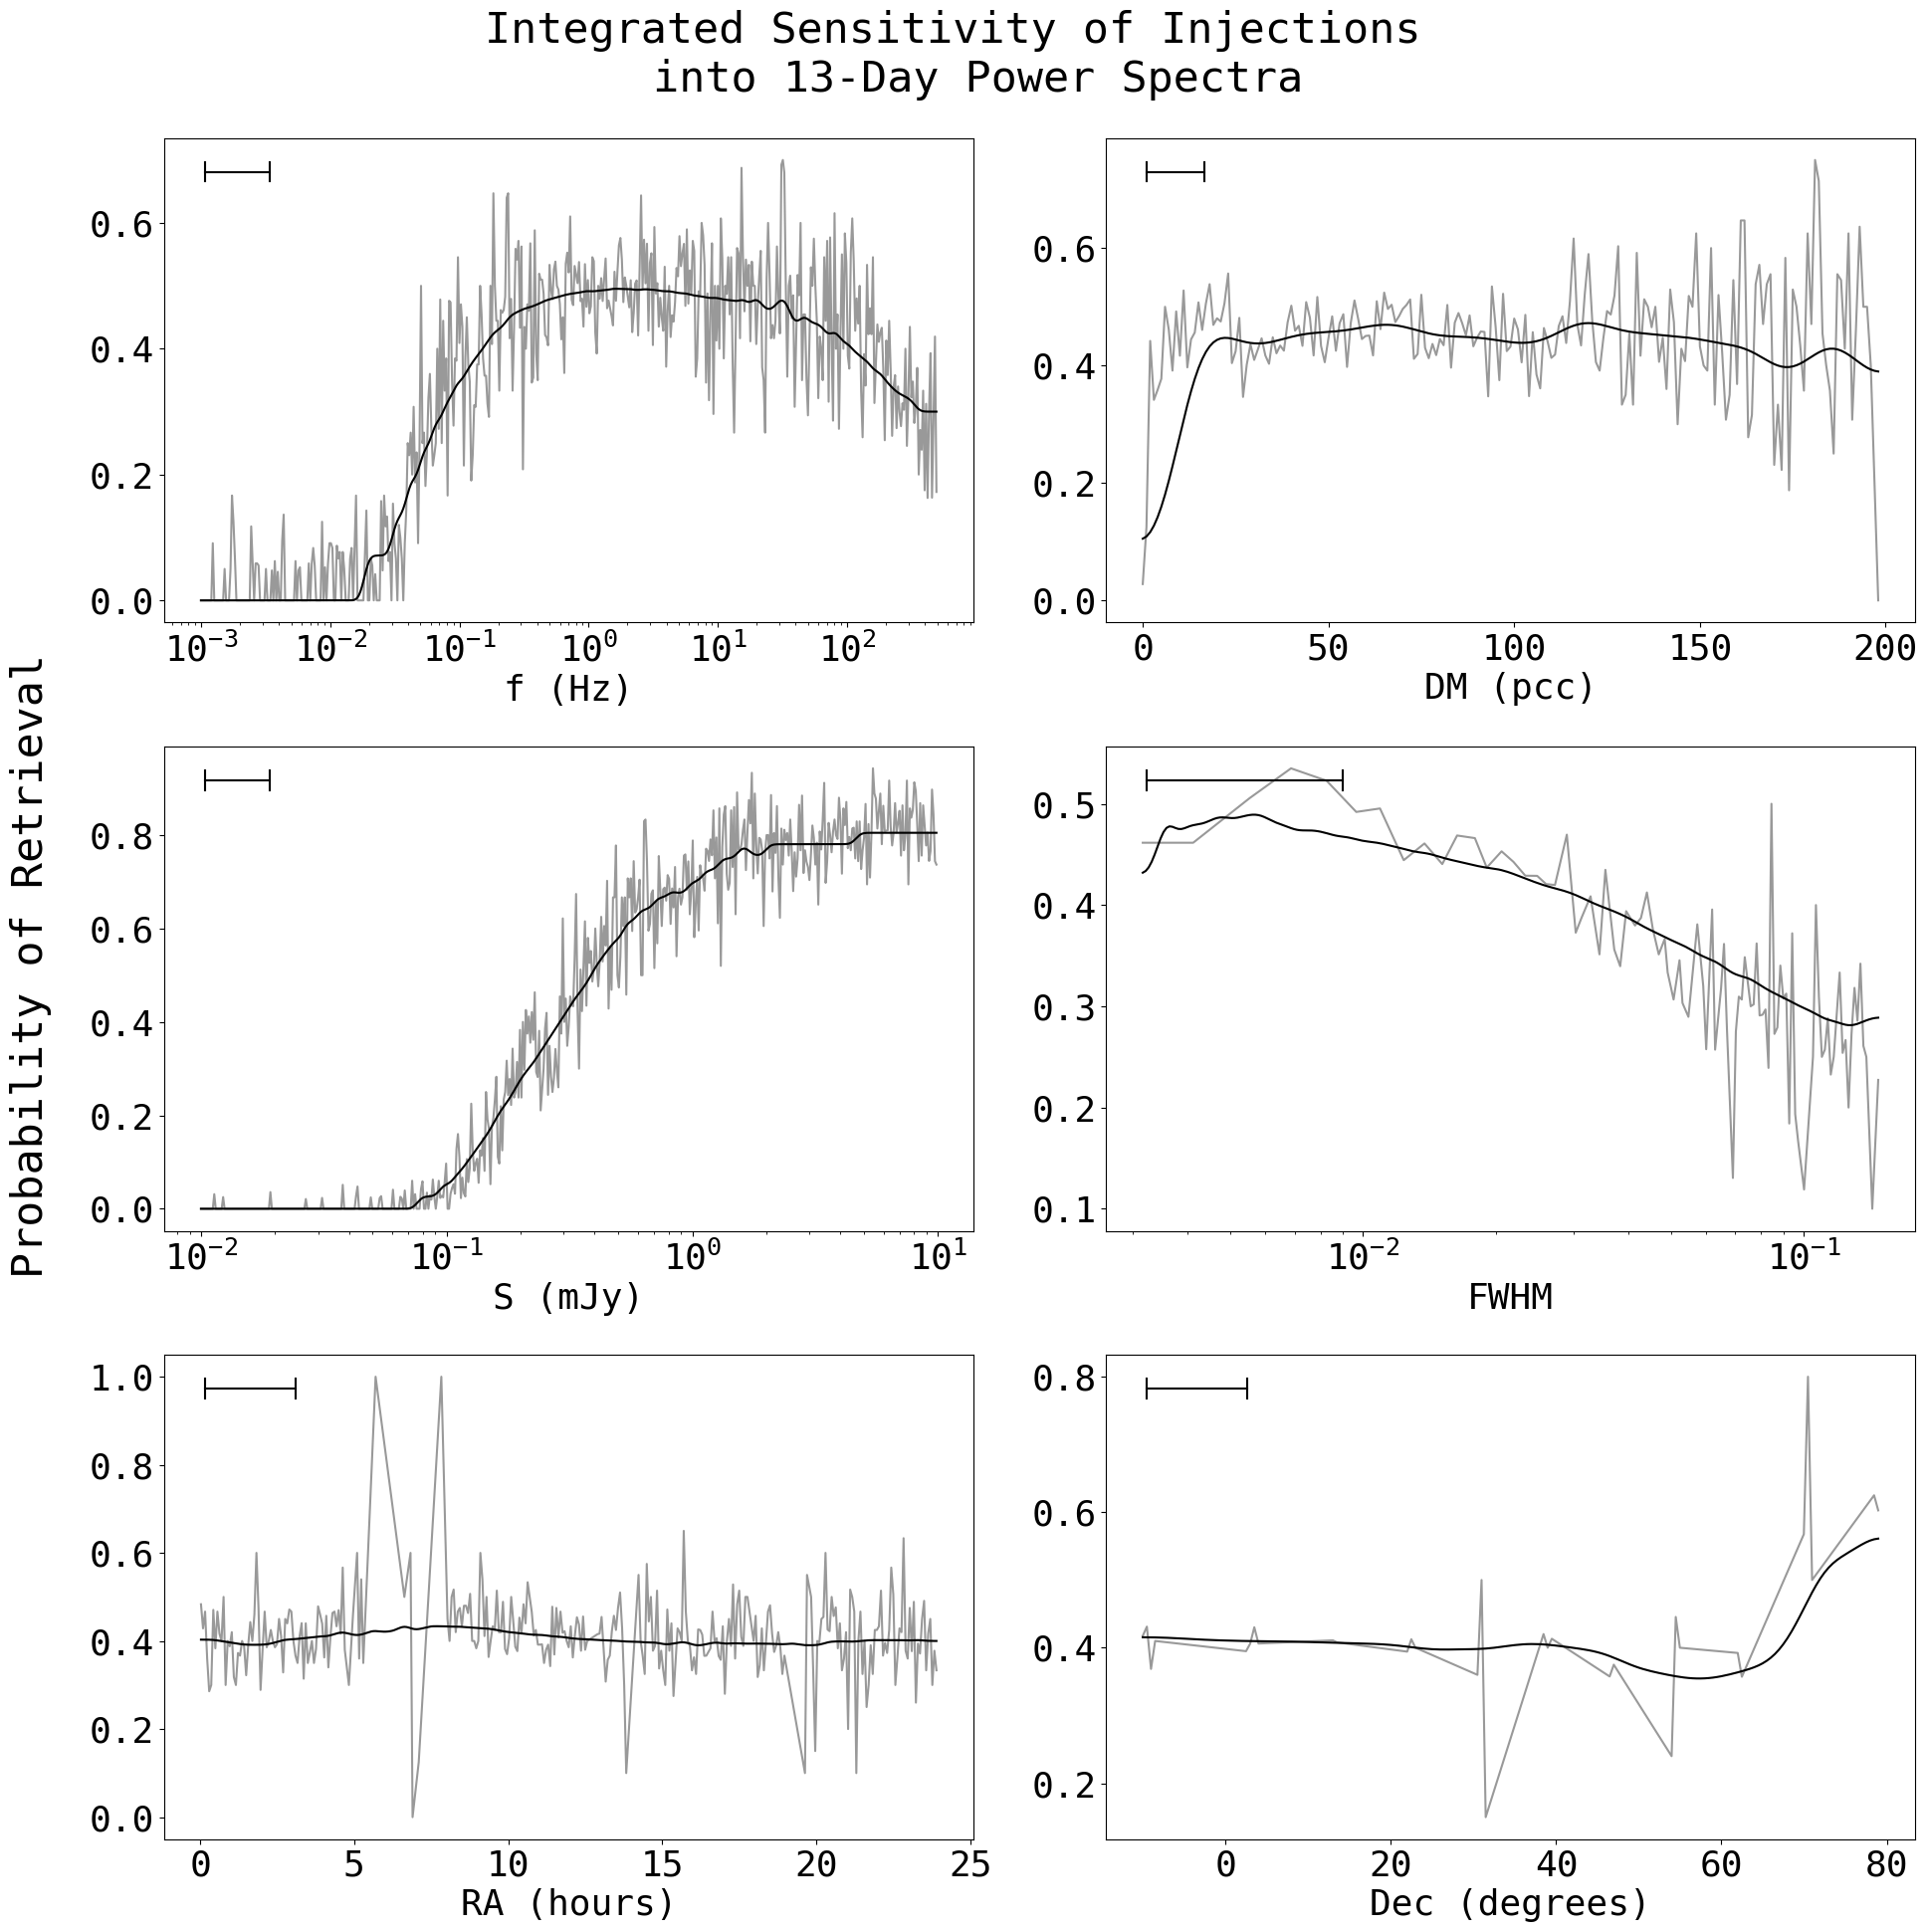

In [64]:
fig, ax = plt.subplots(3, 2, figsize=(20, 20), layout = 'constrained')
ax = ax.flatten()
ax[0].plot(f_bins[:-1], gaussian_filter(f_sens_smooth, 3), color='black', label='Sensitivity')
ax[0].plot(f_bins[:-1], f_sens, alpha=0.4, color='black')
# ax[0].plot(f_bins[:-1], gaussian_filter(f_comp_smooth, 3), color='blue', label='Completeness')
# ax[0].plot(f_bins[:-1], f_comp, alpha=0.4, color='blue')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_sens_smooth, 5), color='black')
ax[1].plot(DM_bins[:-1], DM_sens, alpha=0.4, color='black')
# ax[1].plot(DM_bins[:-1], gaussian_filter(DM_comp_smooth, 3), color='blue')
# ax[1].plot(DM_bins[:-1], DM_comp, alpha=0.4, color='blue')
ax[1].set_xlabel('DM (pcc)')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 5**2))

ax[2].plot(S_bins[:-1], gaussian_filter(S_sens_smooth, 3), color='black')
ax[2].plot(S_bins[:-1], S_sens, alpha=0.4, color='black')
# ax[2].plot(S_bins[:-1], gaussian_filter(S_comp_smooth, 3), color='blue')
# ax[2].plot(S_bins[:-1], S_comp, alpha=0.4, color='blue')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_sens_smooth, 3), color='black')
ax[3].plot(FWHM_bins[:-1], FWHM_sens, alpha=0.4, color='black')
# ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_comp_smooth, 3), color='blue')
# ax[3].plot(FWHM_bins[:-1], FWHM_comp, alpha=0.4, color='blue')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 3**2))

ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_sens_smooth, 3), color='black')
ax[4].plot(RA_bins[:-1] / 15, RA_sens, alpha=0.4, color='black')
# ax[3].plot(RA_bins[:-1], gaussian_filter(RA_comp_smooth, 3), color='blue')
# ax[3].plot(RA_bins[:-1], RA_comp, alpha=0.4, color='blue')
ax[4].set_xlabel('RA (hours)')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_sens_smooth, 5), color='black')
ax[5].plot(Dec_bins[:-1], Dec_sens, alpha=0.4, color='black')
# ax[3].plot(Dec_bins[:-1], gaussian_filter(Dec_comp_smooth, 3), color='blue')
# ax[3].plot(Dec_bins[:-1], Dec_comp, alpha=0.4, color='blue')
ax[5].set_xlabel('Dec (degrees)')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 5**2))

fig.suptitle('Integrated Sensitivity of Injections \n into 13-Day Power Spectra')
fig.supylabel('Probability of Retrieval')
#fig.legend()
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


Text(0.5, 1.0, '13 day spectra, DM < 100 injections')

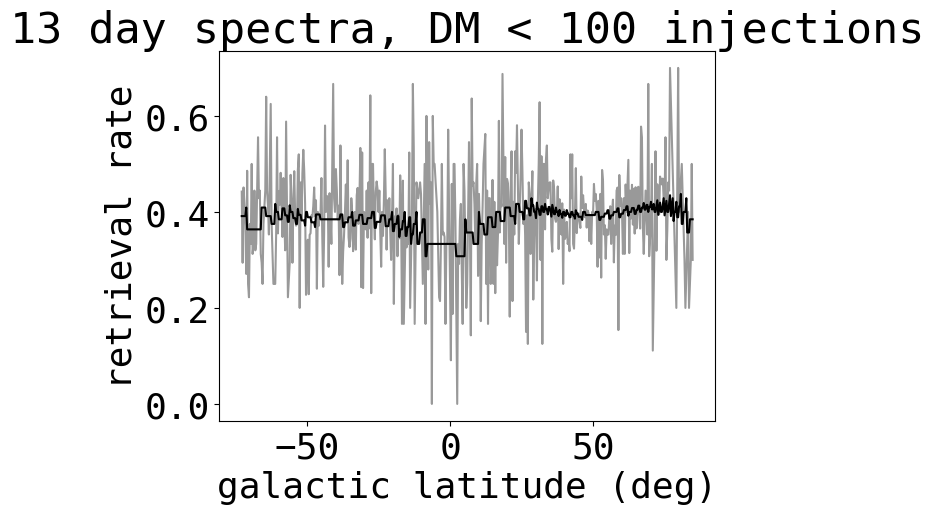

In [67]:
DM_mask = data_13[:, DM_idx] < 100.
b_bins = np.linspace(min(b13.value), max(b13.value), 500)
b_dev = 20
mock_data_13 = np.zeros((len(b13[DM_mask]), 2))
mock_data_13[:, 0] = b13[DM_mask]
mock_data_13[:, 1] = data_13[DM_mask, -1]

b_inj_p_smooth, b_sens, b_sens_smooth = au.get_sensitivity(
    mock_data_13, 
    *(0, b_bins, b_dev)
)

plt.plot(b_bins[:-1], b_sens_smooth, color='black')
plt.plot(b_bins[:-1], b_sens, alpha=0.4, color='black')
plt.xlabel('galactic latitude (deg)')
plt.ylabel('retrieval rate')
plt.title('13 day spectra, DM < 100 injections')

Text(0.5, 1.0, 'single day spectra, DM < 100 injections')

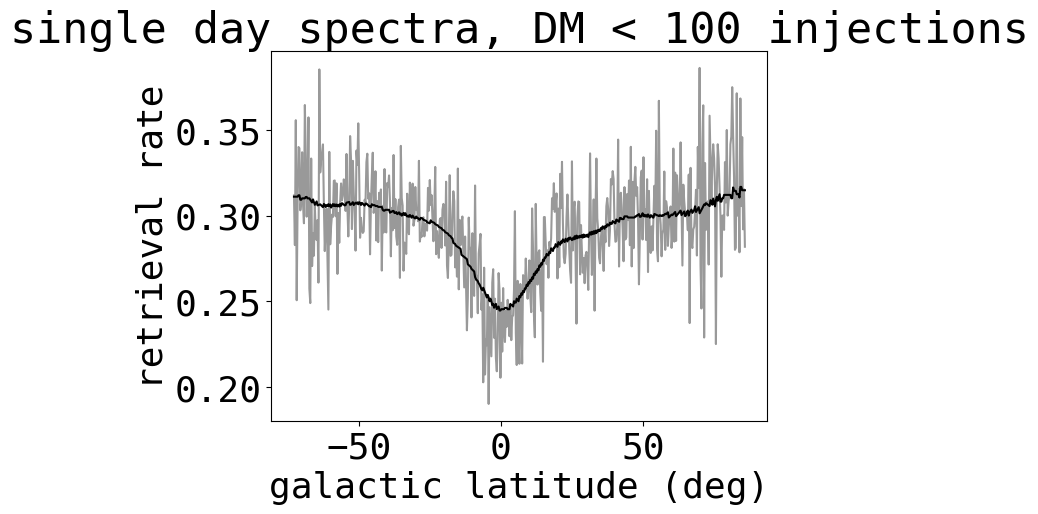

In [68]:
DM_mask = data_1[:, DM_idx] < 100.
b_bins = np.linspace(min(b1.value), max(b1.value), 500)
b_dev = 20
mock_data_1 = np.zeros((len(b1[DM_mask]), 2))
mock_data_1[:, 0] = b1[DM_mask]
mock_data_1[:, 1] = data_1[DM_mask, -1]

b_inj_p_smooth, b_sens, b_sens_smooth = au.get_sensitivity(
    mock_data_1, 
    *(0, b_bins, b_dev)
)

plt.plot(b_bins[:-1], b_sens_smooth, color='black')
plt.plot(b_bins[:-1], b_sens, alpha=0.4, color='black')
plt.xlabel('galactic latitude (deg)')
plt.ylabel('retrieval rate')
plt.title('single day spectra, DM < 100 injections')